In [2]:
# Install Required Libraries
!pip install pandas numpy matplotlib seaborn scipy statsmodels

In [3]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#Load your data
df = pd.read_csv("data.csv")

df.head()

,Unnamed: 0,CA.102548,CA.104338,CA.105094,CA.109745,CA.1906415,CA.1912627,CA.1924346,CA.1926760,CA.1927842,...,CAP.2040686,CAP.2046297,CAP.2046641,CAP.348981,CAP.354300,CAP.359448,CAP.94377,CAP.98389,CAP.98475,CAP.99145
0,TSPAN6,0.93,1.97,0.00,5.45,4.52,4.75,3.96,3.58,6.41,...,6.66,8.35,8.94,6.33,5.94,6.35,3.74,4.84,10.46,4.54
1,TNMD,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.23,0.39,...,0.12,0.17,1.08,0.29,0.00,0.07,9.19,1.18,0.09,0.39
2,DPM1,0.00,0.43,0.00,3.43,8.45,8.53,7.80,7.62,6.40,...,4.93,7.47,5.72,4.96,9.28,9.15,4.77,3.75,7.31,2.77
3,SCYL3,5.78,5.17,8.76,4.58,7.20,6.03,9.05,5.37,5.92,...,8.02,6.00,5.28,4.98,4.45,7.00,4.14,5.51,7.45,2.33
4,C1orf112,2.83,6.26,3.37,6.24,5.16,13.69,6.69,5.28,7.65,...,7.91,4.61,8.35,9.84,7.68,5.62,2.81,7.08,7.28,5.39


Explanation
The dataset is loaded using the pandas library. Each row represents a gene & each column represents expression values for a sample.

In [7]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Data Preparation
df = df.set_index(df.columns[0])
df.head()

,CA.102548,CA.104338,CA.105094,CA.109745,CA.1906415,CA.1912627,CA.1924346,CA.1926760,CA.1927842,CA.1933414,...,CAP.2040686,CAP.2046297,CAP.2046641,CAP.348981,CAP.354300,CAP.359448,CAP.94377,CAP.98389,CAP.98475,CAP.99145
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
TSPAN6,0.93,1.97,0.00,5.45,4.52,4.75,3.96,3.58,6.41,11.89,...,6.66,8.35,8.94,6.33,5.94,6.35,3.74,4.84,10.46,4.54
TNMD,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.23,0.39,0.44,...,0.12,0.17,1.08,0.29,0.00,0.07,9.19,1.18,0.09,0.39
DPM1,0.00,0.43,0.00,3.43,8.45,8.53,7.80,7.62,6.40,6.09,...,4.93,7.47,5.72,4.96,9.28,9.15,4.77,3.75,7.31,2.77
SCYL3,5.78,5.17,8.76,4.58,7.20,6.03,9.05,5.37,5.92,12.45,...,8.02,6.00,5.28,4.98,4.45,7.00,4.14,5.51,7.45,2.33
C1orf112,2.83,6.26,3.37,6.24,5.16,13.69,6.69,5.28,7.65,13.71,...,7.91,4.61,8.35,9.84,7.68,5.62,2.81,7.08,7.28,5.39


Explanation

The first column (gene names) is set as the index so that each row corresponds to a gene.

In [6]:
# Differential Gene Expression
from scipy.stats import ttest_ind
import numpy as np

split = int(df.shape[1] / 2)

results = []

for gene in df.index:
    normal = df.loc[gene].values[:split]
    cancer = df.loc[gene].values[split:]
    
    stat, pval = ttest_ind(normal, cancer)
    fc = np.mean(cancer) - np.mean(normal)
    
    results.append([gene, fc, pval])

res_df = pd.DataFrame(results, columns=["Gene", "logFC", "pvalue"])
res_df.head()

,Gene,logFC,pvalue
0,TSPAN6,2.060333,0.024848
1,TNMD,1.102333,0.032286
2,DPM1,-1.536000,0.149910
3,SCYL3,-2.259000,0.001074
4,C1orf112,-1.498333,0.217213


Explanation

A t-test is performed to compare gene expression between normal and cancer samples.

logFC shows change in expression
p-value shows statistical significance

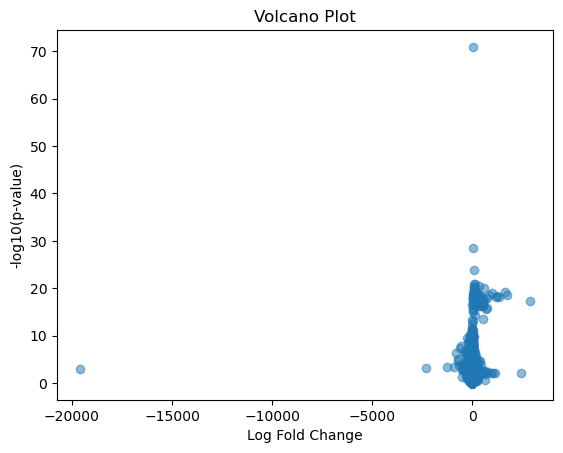

In [8]:
# Volcano Plot
import matplotlib.pyplot as plt
import numpy as np

res_df["-log10(pvalue)"] = -np.log10(res_df["pvalue"])

plt.scatter(res_df["logFC"], res_df["-log10(pvalue)"], alpha=0.5)
plt.xlabel("Log Fold Change")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot")
plt.show()

Explanation

The volcano plot highlights genes that are both highly differentially expressed and statistically significant.

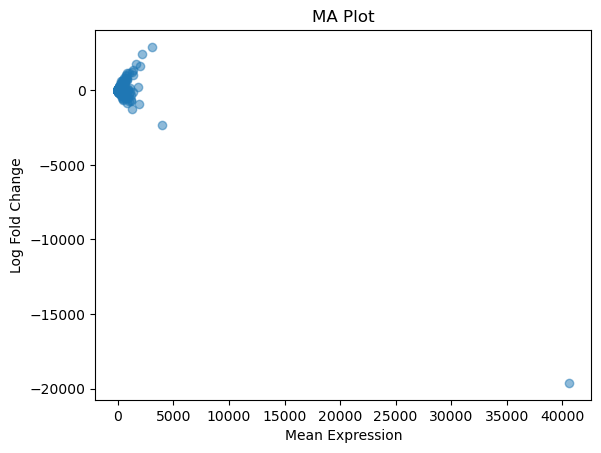

In [11]:
# MA Plot
mean_expr = df.mean(axis=1)

plt.scatter(mean_expr, res_df["logFC"], alpha=0.5)
plt.xlabel("Mean Expression")
plt.ylabel("Log Fold Change")
plt.title("MA Plot")
plt.show()

Explanation

The MA plot visualizes the relationship between average gene expression and differential expression.

In [10]:
# Gene Selection
sig = res_df[res_df["pvalue"] < 0.05]
sig["Gene"].to_csv("gene_list.txt", index=False)

Explanation

Genes with p-value < 0.05 are considered significant and saved for downstream analysis.

In [12]:
# Functional Enrichment
!pip install gseapy

Explanation

We install the gseapy package, which allows gene enrichment analysis similar to DAVID.

In [13]:
# Load library
import gseapy as gp

Explanation

The gseapy library is imported for enrichment analysis.

In [14]:
# Prepare gene list
gene_list = sig["Gene"].tolist()

gene_list[:10]

['TSPAN6',
 'TNMD',
 'SCYL3',
 'CFH',
 'FUCA2',
 'NFYA',
 'BAD',
 'LASP1',
 'M6PR',
 'KLHL13']

Explanation

We convert significant genes into a list format required for enrichment analysis.

In [16]:
# Run Enrichment Analysis
enr = gp.enrichr(
    gene_list=gene_list,
    gene_sets='KEGG_2021_Human',
    organism='hsapiens',
    outdir='enrichr_results',
    cutoff=0.05
)

enr.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Proteasome,34/46,0.000004,0.001202,0,0,4.215206,52.656215,PSMB11;PSMD14;PSMD13;POMP;PSMA7;PSMB10;PSMA8;P...
1,KEGG_2021_Human,Prion disease,142/273,0.000052,0.008306,0,0,1.618351,15.966587,NDUFA13;NDUFA11;NDUFA10;COX6A1;TNF;PSMD8;TUBB8...
2,KEGG_2021_Human,Human cytomegalovirus infection,119/225,0.000081,0.008622,0,0,1.674767,15.781556,CALML5;CCL4L1;CALML3;ELK1;TNF;CRKL;TBK1;CREB3L...
3,KEGG_2021_Human,Hepatitis B,87/162,0.000358,0.018812,0,0,1.728062,13.711672,IFNA4;DDX3X;IFNA6;YWHAB;IFNA2;PIK3CD;ELK1;TNF;...
4,KEGG_2021_Human,Parkinson disease,127/249,0.000366,0.018812,0,0,1.552415,12.285396,NDUFA13;CALML5;NDUFA11;NDUFA10;CALML3;UBE2L6;C...


Explanation

Enrichment analysis identifies biological pathways significantly associated with the differentially expressed genes.

<Axes: title={'center': 'Enrichment Results'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

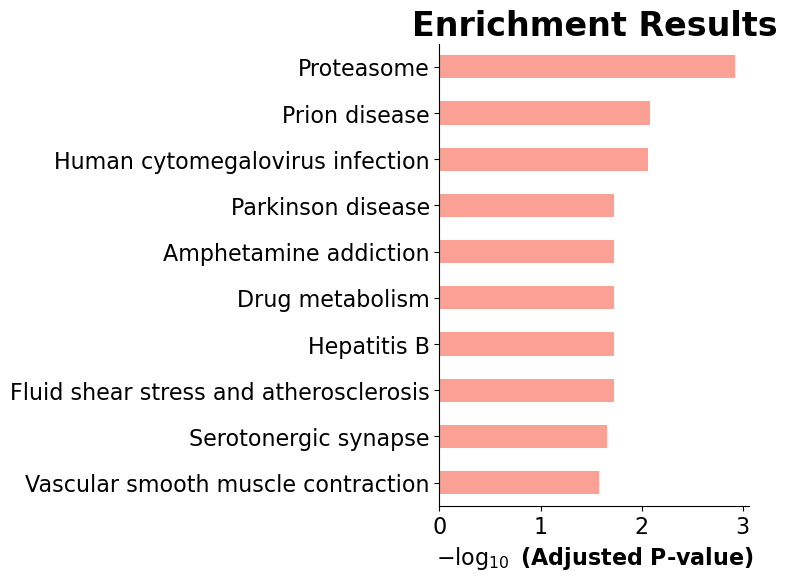

In [17]:
gp.barplot(enr.res2d, title='Enrichment Results')

The bar plot visualizes the most significant biological pathways enriched in the dataset.